# Pakistan CPI & Inflation Analysis
## STAT-222 | BSDS-02 | Semester Project
**Course:** Advanced Statistics  
**Submission:** 4th May 2026  

---

### Data Sources
| Dataset | Source | Purpose | Base Year |
|---|---|---|---|
| `master_WB.csv` | World Bank Global Inflation DB | ARIMA (long series) | 2010=100 |
| `master_IMF.csv` | IMF SDMX API (ECOFIN) | ANOVA + Nonparametric | 2015/16=100 |

> **Why two separate masters?** WB and IMF use incompatible base years and definitions.  
> Merging them into one dataset would invalidate any cross-column comparison.  
> Each method draws from exactly one source — no mixing.


---
## Section 0 — Environment Setup

In [ ]:
!pip install pmdarima pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 16.0 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.stattools import durbin_watson
import pingouin as pg
import pmdarima as pm

# ── Plot style ──────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})
COLORS = ['#2d6a4f','#1a4a7a','#c0392b','#e8845c','#7c4d00','#4a1a7c']

print("✓ All libraries loaded")


✓ All libraries loaded


---
## Section 1 — Data Loading & Validation

In [ ]:
# ── Load Master WB (ARIMA source) ──────────────────────────────
df_wb = pd.read_csv('master_WB.csv', parse_dates=['Date'], index_col='Date')
df_wb = df_wb.sort_index()
assert df_wb.isnull().sum().sum() == 0, "Missing values in WB master!"
print(f"WB master  : {df_wb.shape}  |  {df_wb.index.min().date()} → {df_wb.index.max().date()}")

# ── Load Master IMF (ANOVA + Nonparametric source) ──────────────
df_imf = pd.read_csv('master_IMF.csv', parse_dates=['Date'], index_col='Date')
df_imf = df_imf.sort_index()
assert df_imf.isnull().sum().sum() == 0, "Missing values in IMF master!"
print(f"IMF master : {df_imf.shape}  |  {df_imf.index.min().date()} → {df_imf.index.max().date()}")
print(f"IMF columns: {list(df_imf.columns)}")


WB master  : (201, 1)  |  2008-07-01 → 2025-03-01
IMF master : (45, 7)  |  2022-07-01 → 2026-03-01
IMF columns: ['CPI_Headline', 'CPI_Food', 'CPI_Clothing', 'CPI_Housing', 'CPI_Health', 'CPI_Transport', 'CPI_Education']


---
## Section 2 — Exploratory Data Analysis (EDA)

### 2.1 Descriptive Statistics

In [ ]:
# ── WB Headline descriptive stats ──────────────────────────────
wb_mom = df_wb['CPI_Headline'].pct_change(1).dropna() * 100
wb_yoy = df_wb['CPI_Headline'].pct_change(12).dropna() * 100

print("=== WB CPI Headline (Index Level) ===")
print(df_wb['CPI_Headline'].describe().round(2))

print("\n=== Month-on-Month Inflation % (WB) ===")
print(wb_mom.describe().round(4))
print(f"Skewness : {wb_mom.skew():.4f}")
print(f"Kurtosis : {wb_mom.kurt():.4f}")

print("\n=== IMF Sub-Category Index Levels ===")
print(df_imf.describe().round(2))


=== WB CPI Headline (Index Level) ===
count    201.00
mean     123.08
std       58.47
min       55.12
25%       84.59
50%      103.49
75%      141.83
max      266.29
Name: CPI_Headline, dtype: float64

=== Month-on-Month Inflation % (WB) ===
count    200.0000
mean       0.7969
std        1.1294
min       -3.2436
25%        0.1283
50%        0.6290
75%        1.3969
max        6.3444
Name: CPI_Headline, dtype: float64
Skewness : 0.9944
Kurtosis : 3.8655

=== IMF Sub-Category Index Levels ===
       CPI_Headline  CPI_Food  CPI_Clothing  CPI_Housing  CPI_Health  \
count         45.00     45.00         45.00        45.00       45.00   
mean         248.18    268.02        230.72       219.29      238.89   
std           29.67     26.55         32.34        32.89       36.45   
min          183.35    195.27        171.40       150.24      171.65   
25%          227.96    264.01        205.16       182.46      204.10   
50%          260.96    276.85        239.46       236.43      241.17   


### 2.2 Time Series Plot — WB Headline CPI

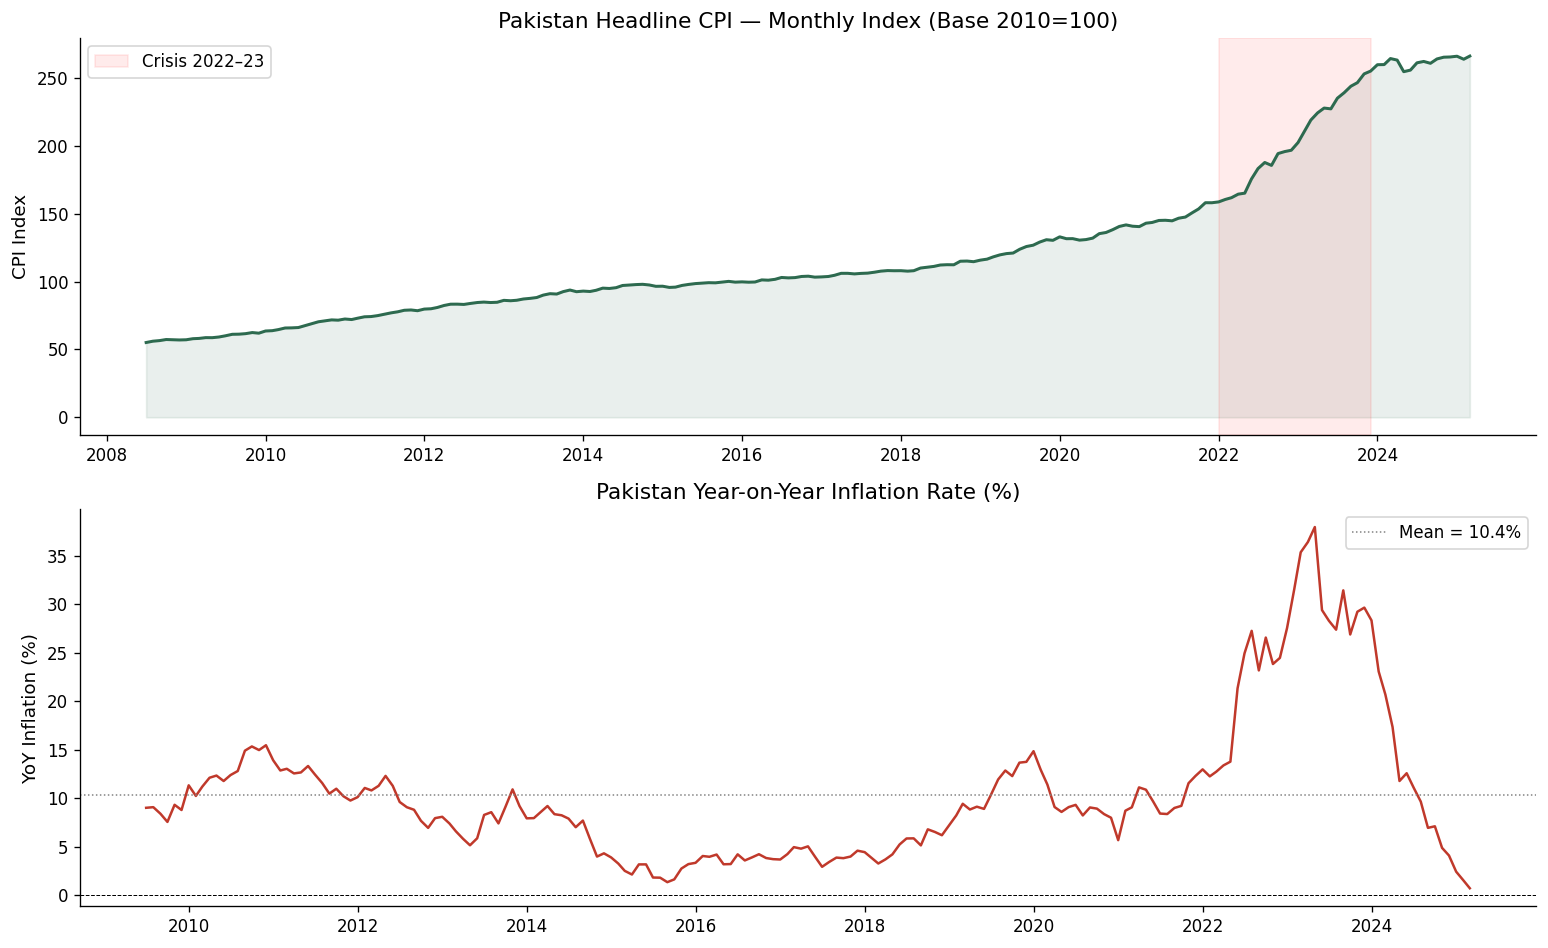

✓ Saved plot_01_cpi_timeseries.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# CPI level
axes[0].plot(df_wb.index, df_wb['CPI_Headline'], color=COLORS[0], linewidth=1.8)
axes[0].fill_between(df_wb.index, df_wb['CPI_Headline'], alpha=0.1, color=COLORS[0])
axes[0].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='red', label='Crisis 2022–23')
axes[0].set_title('Pakistan Headline CPI — Monthly Index (Base 2010=100)')
axes[0].set_ylabel('CPI Index')
axes[0].legend()

# YoY inflation rate
axes[1].plot(wb_yoy.index, wb_yoy, color=COLORS[2], linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].axhline(wb_yoy.mean(), color='grey', linewidth=0.9, linestyle=':', label=f'Mean = {wb_yoy.mean():.1f}%')
axes[1].set_title('Pakistan Year-on-Year Inflation Rate (%)')
axes[1].set_ylabel('YoY Inflation (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_01_cpi_timeseries.png', bbox_inches='tight')
plt.show()
print("✓ Saved plot_01_cpi_timeseries.png")


### 2.3 Sub-Category CPI — Box Plots & Correlation Heatmap

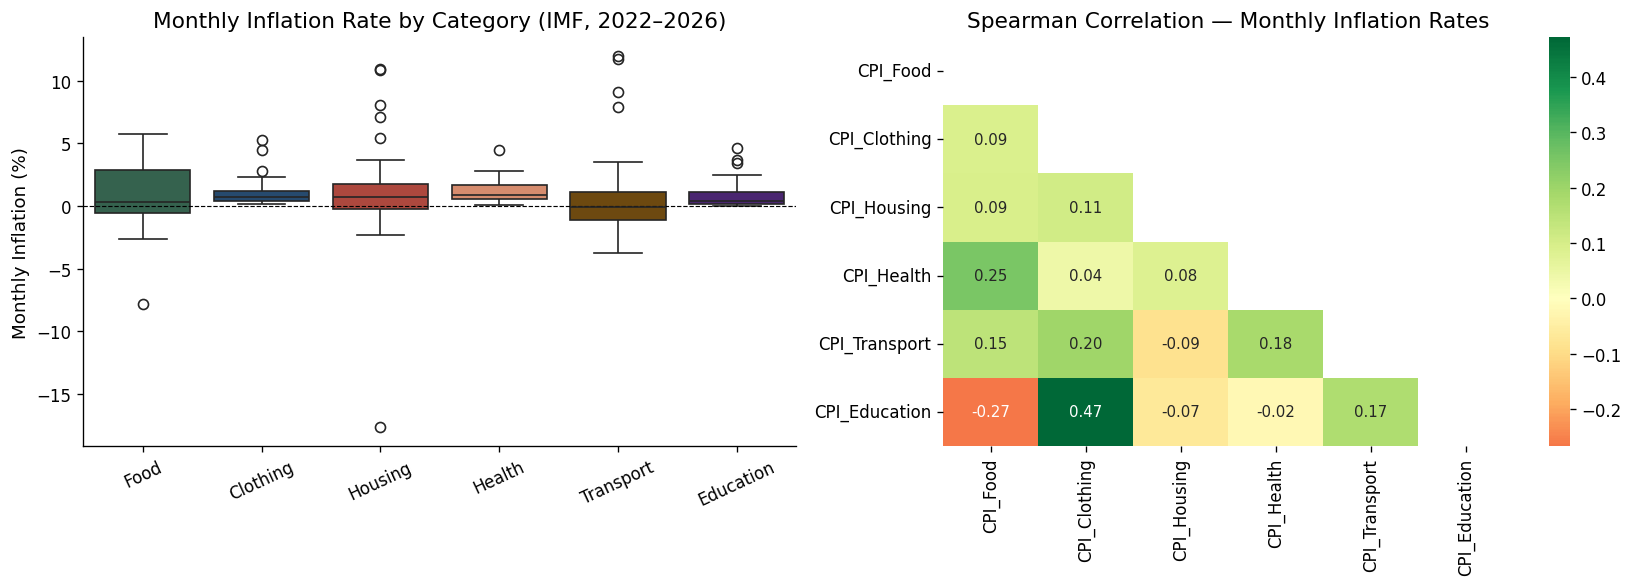

✓ Saved plot_02_eda_subcategories.png


In [ ]:
SUB_COLS = ['CPI_Food','CPI_Clothing','CPI_Housing',
            'CPI_Health','CPI_Transport','CPI_Education']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots of monthly inflation rates per category
inf_rates = df_imf[SUB_COLS].pct_change(1).dropna() * 100
inf_long = inf_rates.reset_index().melt(id_vars='Date',
                                         var_name='Category',
                                         value_name='Monthly_Inflation_pct')
inf_long['Category'] = inf_long['Category'].str.replace('CPI_', '')

sns.boxplot(data=inf_long, x='Category', y='Monthly_Inflation_pct',
            palette=COLORS, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_title('Monthly Inflation Rate by Category (IMF, 2022–2026)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Monthly Inflation (%)')
axes[0].tick_params(axis='x', rotation=25)

# Correlation heatmap
corr = inf_rates.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=axes[1],
            annot_kws={'size': 9})
axes[1].set_title('Spearman Correlation — Monthly Inflation Rates')

plt.tight_layout()
plt.savefig('plot_02_eda_subcategories.png', bbox_inches='tight')
plt.show()
print("✓ Saved plot_02_eda_subcategories.png")


### 2.4 Histogram & Distribution of Monthly Inflation

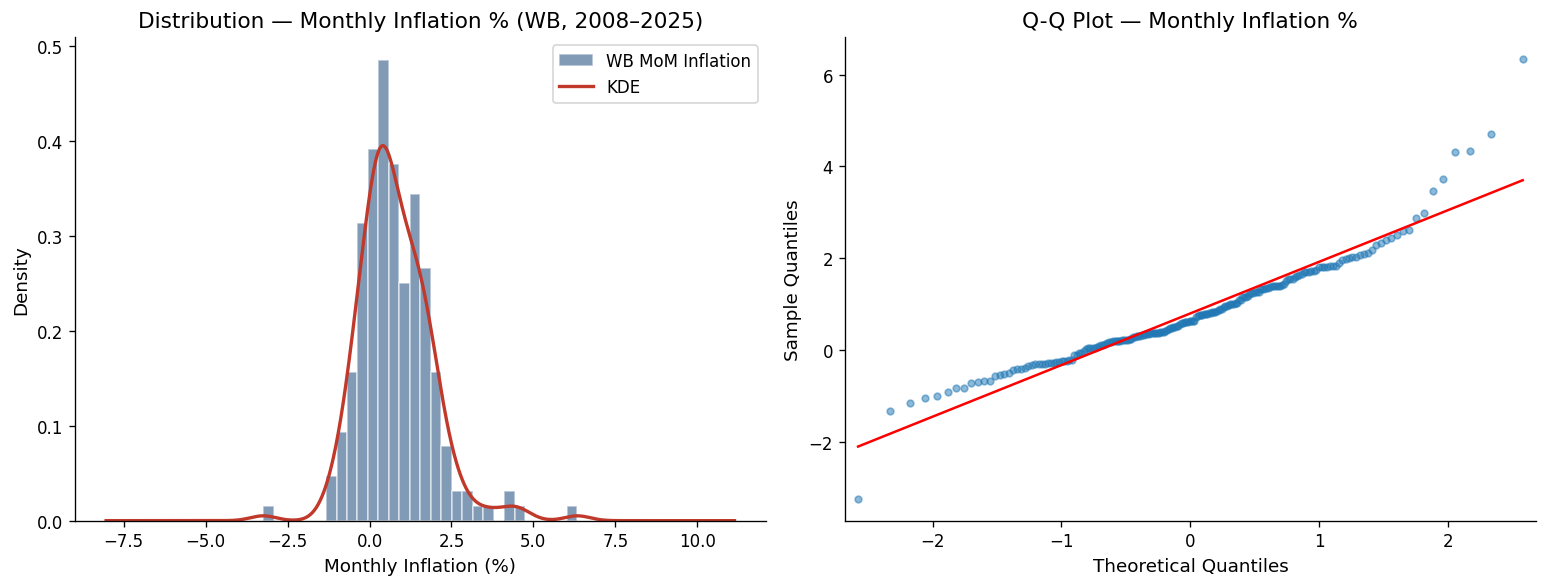

Shapiro-Wilk: stat=0.9366, p=0.000000
→ Non-normal (p<0.05) — confirms nonparametric approach
Skewness: 0.9944  |  Kurtosis (excess): 3.8655


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram with KDE
axes[0].hist(wb_mom, bins=30, density=True, alpha=0.55,
             color=COLORS[1], edgecolor='white', label='WB MoM Inflation')
wb_mom.plot.kde(ax=axes[0], color=COLORS[2], linewidth=2, label='KDE')
axes[0].set_title('Distribution — Monthly Inflation % (WB, 2008–2025)')
axes[0].set_xlabel('Monthly Inflation (%)')
axes[0].legend()

# Q-Q plot
sm.qqplot(wb_mom, line='s', ax=axes[1], alpha=0.5, markersize=4)
axes[1].set_title('Q-Q Plot — Monthly Inflation %')

plt.tight_layout()
plt.savefig('plot_03_distribution_eda.png', bbox_inches='tight')
plt.show()

stat, p = stats.shapiro(wb_mom)
print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.6f}")
print(f"→ {'Non-normal (p<0.05) — confirms nonparametric approach' if p<0.05 else 'Normal (p>0.05)'}")
print(f"Skewness: {wb_mom.skew():.4f}  |  Kurtosis (excess): {wb_mom.kurt():.4f}")


---
## Section 3 — Method 1: Time Series Analysis (ARIMA)

**Source:** `master_WB.csv`  
**Variable:** `CPI_Headline` (monthly index, 201 observations, 2008–2025)  

**Hypotheses:**  
- H₀: The CPI series has a unit root (non-stationary, not predictable)  
- H₁: After differencing, the series is stationary and exhibits predictable autocorrelation structure


### 3.1 Stationarity Tests — ADF & KPSS

In [ ]:
series = df_wb['CPI_Headline'].dropna()

def adf_test(s, label=''):
    result = adfuller(s, autolag='AIC')
    print(f"ADF Test — {label}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    print(f"  Critical 5%: {result[4]['5%']:.4f}")
    conclusion = "STATIONARY ✓" if result[1] < 0.05 else "NON-STATIONARY ✗ → needs differencing"
    print(f"  → {conclusion}\n")
    return result[1] < 0.05

def kpss_test(s, label=''):
    stat, p, lags, crit = kpss(s, regression='ct', nlags='auto')
    print(f"KPSS Test — {label}")
    print(f"  Statistic : {stat:.4f}")
    print(f"  p-value   : {p:.4f}")
    conclusion = "STATIONARY ✓" if p > 0.05 else "NON-STATIONARY ✗"
    print(f"  → {conclusion}\n")

# Level series
print("=" * 50)
stat_level = adf_test(series, 'CPI Level')
kpss_test(series, 'CPI Level')

# First difference
series_d1 = series.diff().dropna()
print("=" * 50)
stat_d1 = adf_test(series_d1, 'First Difference')
kpss_test(series_d1, 'First Difference')

# Log + First difference (handles heteroscedasticity)
log_series = np.log(series)
log_d1 = log_series.diff().dropna()
print("=" * 50)
stat_log = adf_test(log_d1, 'Log + First Difference')
kpss_test(log_d1, 'Log + First Difference')


ADF Test — CPI Level
  Statistic : 1.4908
  p-value   : 0.9975
  Critical 5%: -2.8773
  → NON-STATIONARY ✗ → needs differencing

KPSS Test — CPI Level
  Statistic : 0.4045
  p-value   : 0.0100
  → NON-STATIONARY ✗

ADF Test — First Difference
  Statistic : -1.8738
  p-value   : 0.3445
  Critical 5%: -2.8770
  → NON-STATIONARY ✗ → needs differencing

KPSS Test — First Difference
  Statistic : 0.1960
  p-value   : 0.0175
  → NON-STATIONARY ✗

ADF Test — Log + First Difference
  Statistic : -2.4800
  p-value   : 0.1204
  Critical 5%: -2.8769
  → NON-STATIONARY ✗ → needs differencing

KPSS Test — Log + First Difference
  Statistic : 0.2141
  p-value   : 0.0107
  → NON-STATIONARY ✗



### 3.2 ACF & PACF Plots

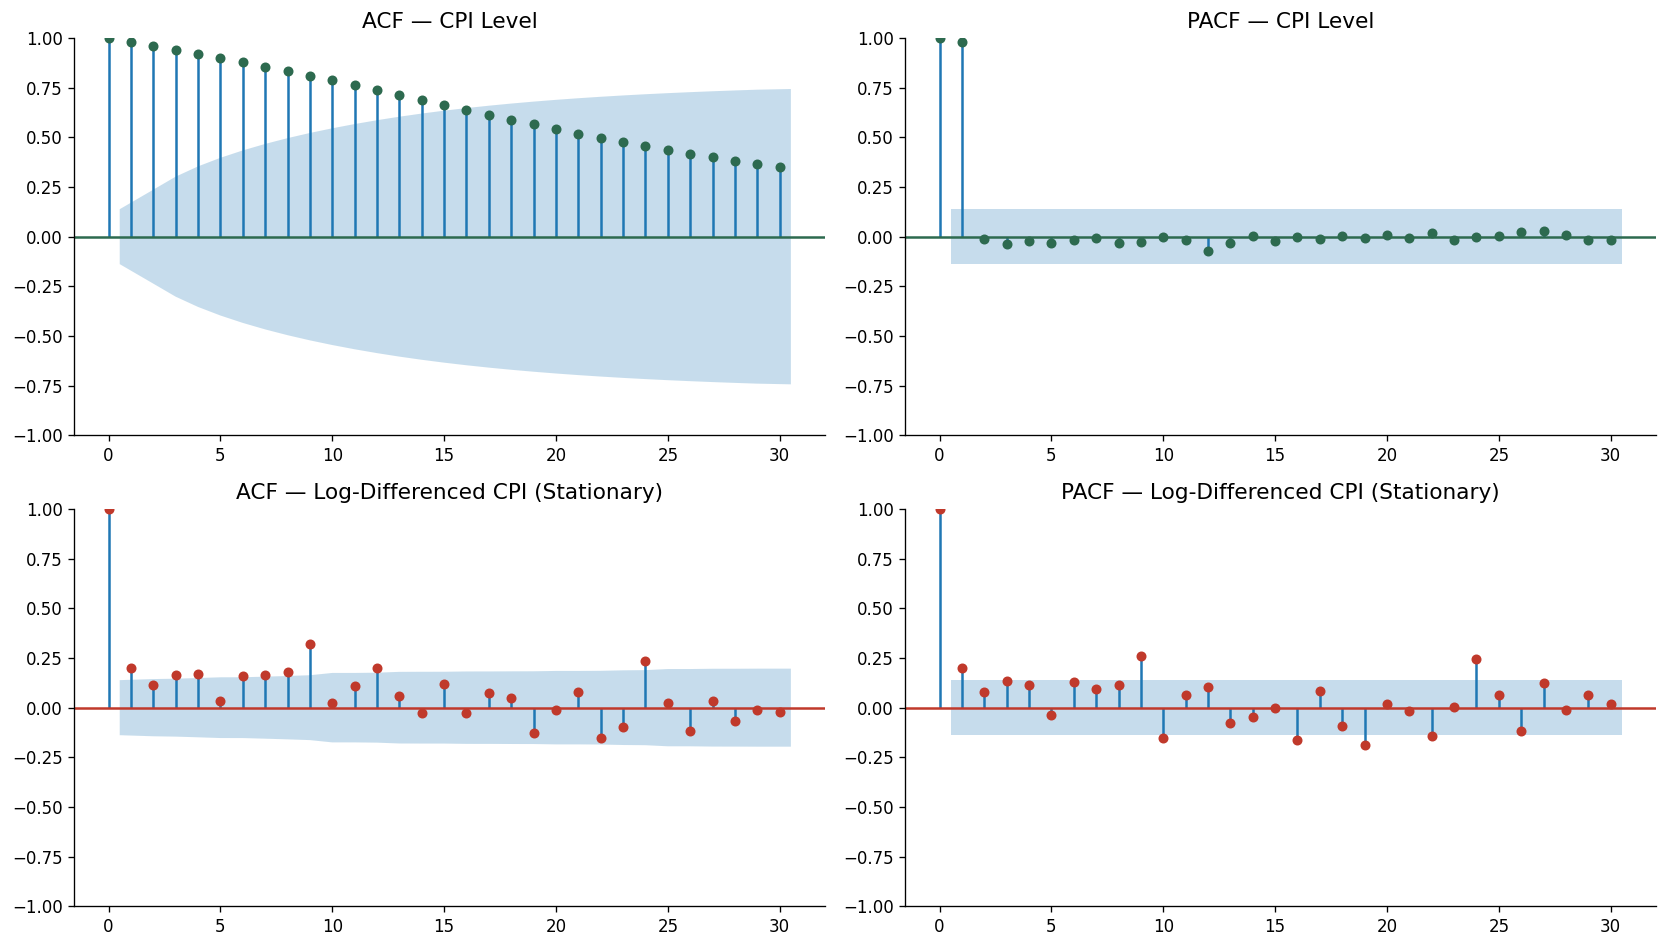

✓ ACF/PACF saved

Reading guide:
  ACF cuts off at lag q  → MA(q) component
  PACF cuts off at lag p → AR(p) component
  d = 1 (one log-difference made it stationary)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Level
plot_acf(series, lags=30, ax=axes[0, 0], color=COLORS[0])
axes[0, 0].set_title('ACF — CPI Level')

plot_pacf(series, lags=30, ax=axes[0, 1], color=COLORS[0])
axes[0, 1].set_title('PACF — CPI Level')

# Log-differenced
plot_acf(log_d1, lags=30, ax=axes[1, 0], color=COLORS[2])
axes[1, 0].set_title('ACF — Log-Differenced CPI (Stationary)')

plot_pacf(log_d1, lags=30, ax=axes[1, 1], color=COLORS[2])
axes[1, 1].set_title('PACF — Log-Differenced CPI (Stationary)')

plt.tight_layout()
plt.savefig('plot_04_acf_pacf.png', bbox_inches='tight')
plt.show()
print("✓ ACF/PACF saved")
print("\nReading guide:")
print("  ACF cuts off at lag q  → MA(q) component")
print("  PACF cuts off at lag p → AR(p) component")
print("  d = 1 (one log-difference made it stationary)")


### 3.3 Fit ARIMA — auto_arima selects optimal (p,d,q)

In [ ]:
# Use log-transformed series so model works in log-space
# auto_arima searches over p/q combinations and selects best by AIC
arima_model = pm.auto_arima(
    log_series,
    d=1,                    # force d=1 (confirmed by ADF)
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    error_action='ignore',
    suppress_warnings=True,
    trace=True
)

print("\n" + "="*55)
print(f"Selected order: ARIMA{arima_model.order}")
print("="*55)
print(arima_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1228.066, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1234.162, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1233.097, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1148.750, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-1233.406, Time=0.16 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-1242.432, Time=0.40 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-1235.077, Time=0.51 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-1237.953, Time=0.47 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-1231.949, Time=0.38 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-1237.591, Time=0.66 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-1239.593, Time=0.18 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 3.321 seconds

Selected order: ARIMA(1, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                  

### 3.4 Residual Diagnostics

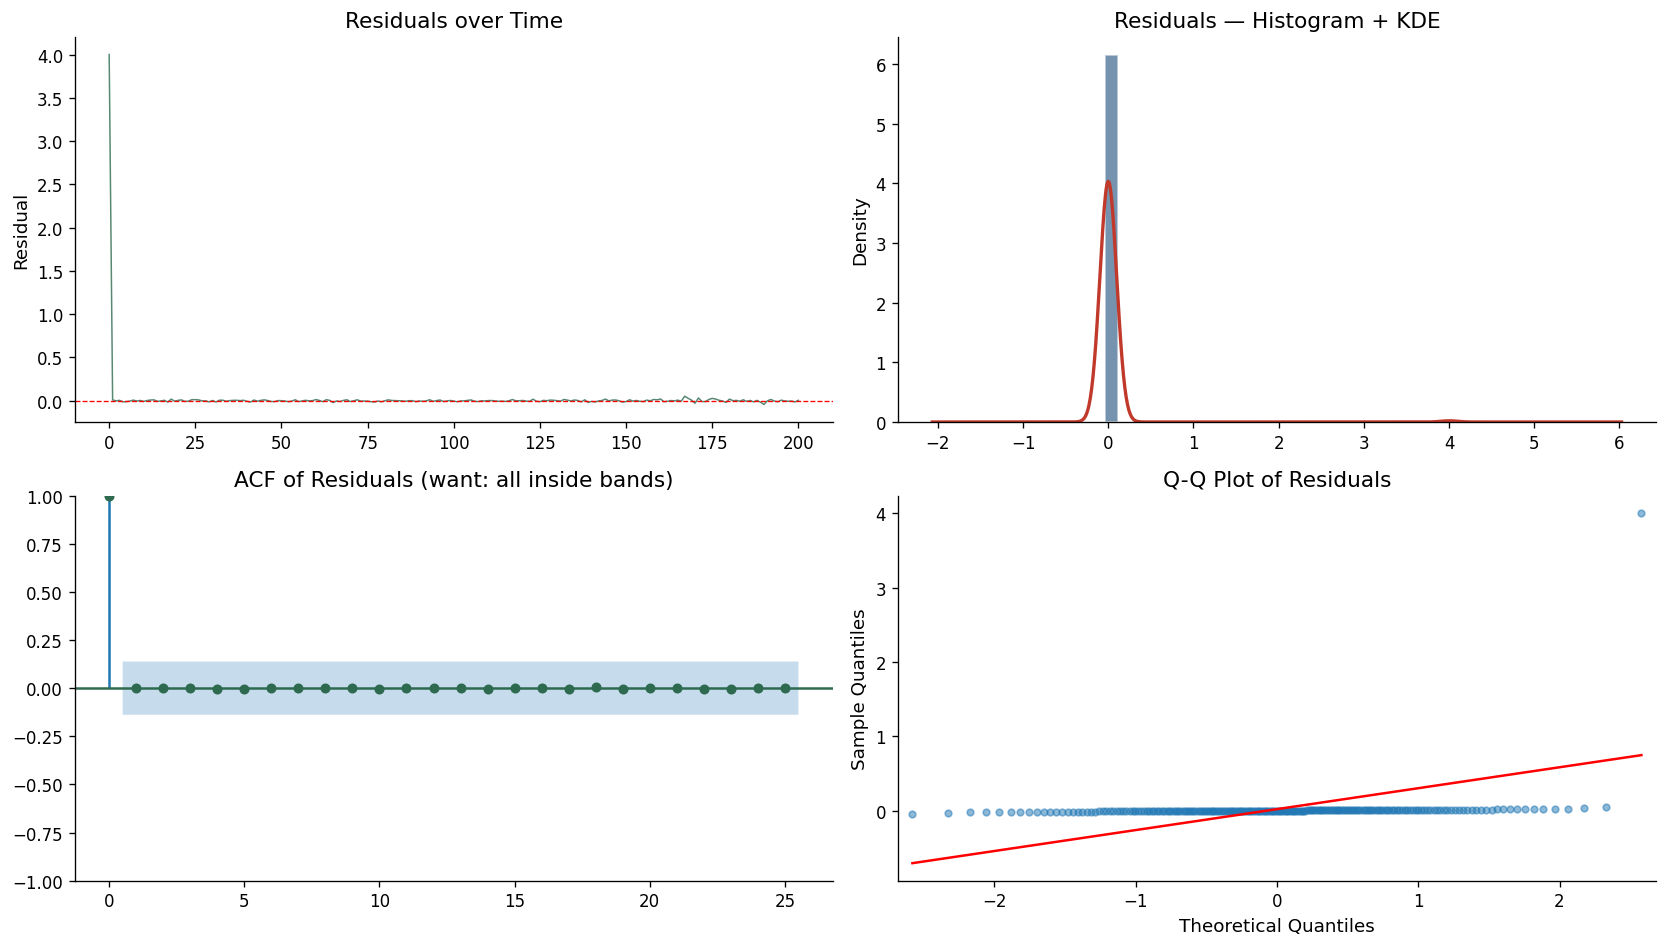

Ljung-Box Test (p > 0.05 → residuals are white noise):
     lb_stat  lb_pvalue
10  0.008061        1.0
20  0.020541        1.0

Durbin-Watson: 0.9965 (want ≈ 2.0, confirms no autocorrelation)
Shapiro-Wilk on residuals: p=0.0000


In [ ]:
residuals = pd.Series(arima_model.resid())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
axes[0, 0].plot(residuals.values, color=COLORS[0], linewidth=0.9, alpha=0.8)
axes[0, 0].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].set_ylabel('Residual')

# Histogram of residuals
axes[0, 1].hist(residuals, bins=25, density=True, color=COLORS[1],
                alpha=0.6, edgecolor='white')
residuals.plot.kde(ax=axes[0, 1], color=COLORS[2], linewidth=2)
axes[0, 1].set_title('Residuals — Histogram + KDE')

# ACF of residuals (should be white noise)
plot_acf(residuals, lags=25, ax=axes[1, 0], color=COLORS[0])
axes[1, 0].set_title('ACF of Residuals (want: all inside bands)')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1, 1], alpha=0.5, markersize=4)
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('plot_05_arima_diagnostics.png', bbox_inches='tight')
plt.show()

# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("Ljung-Box Test (p > 0.05 → residuals are white noise):")
print(lb)

dw = durbin_watson(residuals)
print(f"\nDurbin-Watson: {dw:.4f} (want ≈ 2.0, confirms no autocorrelation)")

res_stat, res_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk on residuals: p={res_p:.4f}")


### 3.5 Forecast — 12 Months Ahead

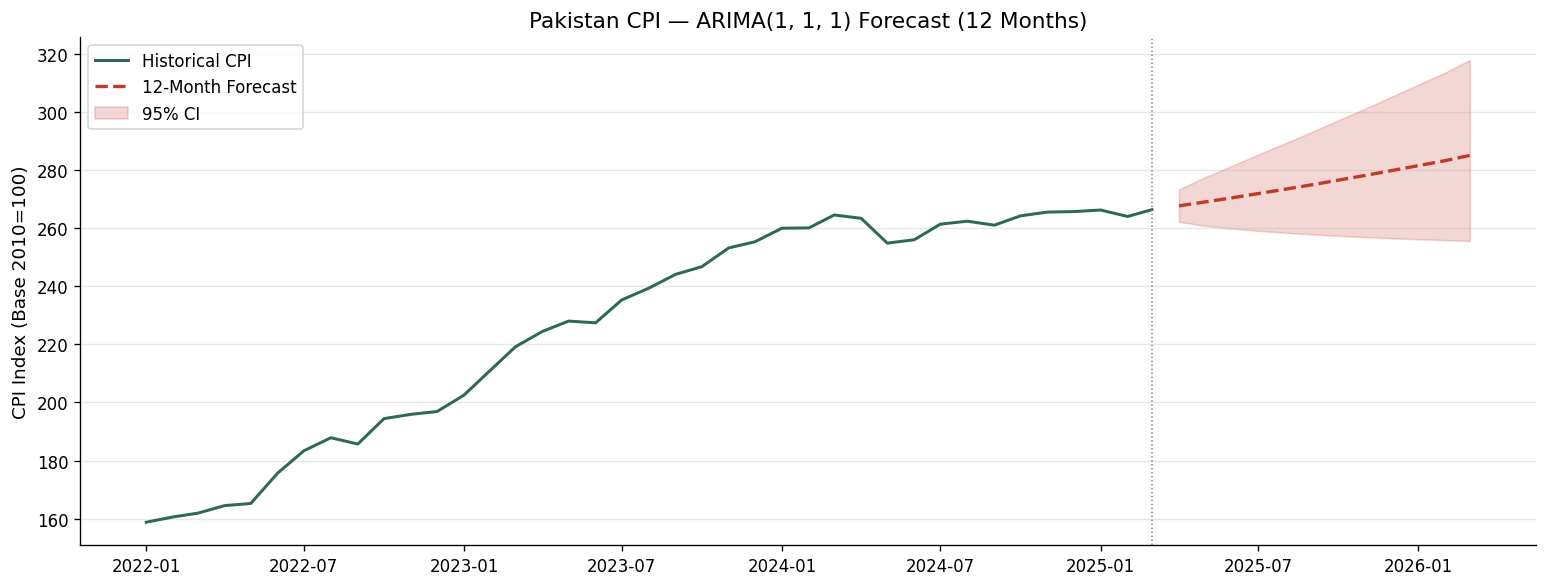

  Month  Forecast_CPI  Lower_95  Upper_95
2025-04        267.60    262.10    273.22
2025-05        268.96    260.74    277.44
2025-06        270.37    259.79    281.38
2025-07        271.82    259.02    285.26
2025-08        273.32    258.36    289.14
2025-09        274.86    257.80    293.06
2025-10        276.45    257.30    297.02
2025-11        278.07    256.85    301.04
2025-12        279.74    256.46    305.12
2026-01        281.44    256.11    309.27
2026-02        283.18    255.81    313.47
2026-03        284.95    255.55    317.74


In [ ]:
n_forecast = 12
forecast_log, conf_int_log = arima_model.predict(n_periods=n_forecast,
                                                   return_conf_int=True)

# Back-transform from log to original scale
forecast_vals = np.exp(forecast_log)
conf_lo = np.exp(conf_int_log[:, 0])
conf_hi = np.exp(conf_int_log[:, 1])

# Build forecast date index
last_date = series.index[-1]
forecast_idx = pd.date_range(start=last_date + pd.offsets.MonthBegin(1),
                              periods=n_forecast, freq='MS')

fig, ax = plt.subplots(figsize=(13, 5))

# Historical (last 3 years for clarity)
hist = series[series.index >= '2022-01-01']
ax.plot(hist.index, hist, color=COLORS[0], linewidth=1.8, label='Historical CPI')

# Forecast
ax.plot(forecast_idx, forecast_vals, color=COLORS[2],
        linewidth=2, linestyle='--', label='12-Month Forecast')
ax.fill_between(forecast_idx, conf_lo, conf_hi,
                alpha=0.2, color=COLORS[2], label='95% CI')

ax.axvline(last_date, color='grey', linewidth=0.9, linestyle=':')
ax.set_title(f'Pakistan CPI — ARIMA{arima_model.order} Forecast (12 Months)')
ax.set_ylabel('CPI Index (Base 2010=100)')
ax.legend()
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_06_arima_forecast.png', bbox_inches='tight')
plt.show()

# Print forecast table
forecast_df = pd.DataFrame({
    'Month': forecast_idx.strftime('%Y-%m'),
    'Forecast_CPI': forecast_vals.round(2),
    'Lower_95': conf_lo.round(2),
    'Upper_95': conf_hi.round(2)
})
print(forecast_df.to_string(index=False))


---
## Section 4 — Method 2: One-Way ANOVA (+ Kruskal-Wallis)

**Source:** `master_IMF.csv`  
**Variable:** Monthly % change of each sub-category (stationary, comparable)  
**Groups:** Food, Clothing, Housing, Health, Transport, Education (6 groups × 44 obs = 264 total)

**Hypotheses:**  
- H₀: Mean monthly inflation rates are equal across all CPI sub-categories  
  μ_Food = μ_Clothing = μ_Housing = μ_Health = μ_Transport = μ_Education  
- H₁: At least one sub-category has a significantly different mean inflation rate (α = 0.05)


### 4.1 Create Analysis Views (in-memory, from master_IMF)

In [ ]:
SUB_COLS = ['CPI_Food','CPI_Clothing','CPI_Housing',
            'CPI_Health','CPI_Transport','CPI_Education']

# Wide view — monthly inflation rates
df_wide = df_imf[SUB_COLS].pct_change(1).dropna() * 100
df_wide.columns = [c.replace('CPI_','') for c in df_wide.columns]
print(f"Wide view: {df_wide.shape}")
print(df_wide.describe().round(4))

# Long view — required by ANOVA functions
df_long = df_wide.reset_index().melt(
    id_vars='Date',
    var_name='Category',
    value_name='Monthly_Inflation_pct'
)
print(f"\nLong view: {df_long.shape}")
print(f"Observations per group:\n{df_long.groupby('Category').size()}")


Wide view: (44, 6)
          Food  Clothing  Housing   Health  Transport  Education
count  44.0000   44.0000  44.0000  44.0000    44.0000    44.0000
mean    0.9242    1.0773   1.0720   1.1961     0.8401     0.8286
std     2.6962    1.0647   4.1302   0.8911     3.4091     1.0361
min    -7.8279    0.2002 -17.6588   0.0666    -3.7214     0.0000
25%    -0.5156    0.4158  -0.2567   0.5593    -1.0690     0.1665
50%     0.3450    0.6959   0.6924   0.9234    -0.0633     0.4196
75%     2.9133    1.2352   1.7828   1.7214     1.1410     1.1198
max     5.7646    5.2739  10.9599   4.4682    12.0126     4.6400

Long view: (264, 3)
Observations per group:
Category
Clothing     44
Education    44
Food         44
Health       44
Housing      44
Transport    44
dtype: int64


### 4.2 ANOVA Assumption Checks

In [ ]:
print("=" * 60)
print("ASSUMPTION 1: Normality — Shapiro-Wilk per group")
print("=" * 60)
normality_results = []
for cat in df_wide.columns:
    grp = df_wide[cat].dropna()
    stat, p = stats.shapiro(grp)
    normal = p > 0.05
    normality_results.append({'Category': cat, 'W': round(stat,4),
                               'p_value': round(p,4), 'Normal': normal})
    print(f"  {cat:<12}  W={stat:.4f}  p={p:.4f}  → {'✓ Normal' if normal else '✗ Non-normal'}")

n_normal = sum(r['Normal'] for r in normality_results)
print(f"\n  {n_normal}/6 groups pass normality")
if n_normal < 6:
    print("  → Kruskal-Wallis will be run alongside ANOVA as the nonparametric alternative")

print("\n" + "=" * 60)
print("ASSUMPTION 2: Homogeneity of Variances — Levene's Test")
print("=" * 60)
groups_list = [df_wide[c].dropna() for c in df_wide.columns]
lev_stat, lev_p = stats.levene(*groups_list)
print(f"  Levene: F={lev_stat:.4f}  p={lev_p:.4f}")
print(f"  → {'✓ Equal variances' if lev_p>0.05 else '✗ Unequal variances — note as limitation'}")


ASSUMPTION 1: Normality — Shapiro-Wilk per group
  Food          W=0.9495  p=0.0529  → ✓ Normal
  Clothing      W=0.7256  p=0.0000  → ✗ Non-normal
  Housing       W=0.7479  p=0.0000  → ✗ Non-normal
  Health        W=0.8859  p=0.0004  → ✗ Non-normal
  Transport     W=0.7650  p=0.0000  → ✗ Non-normal
  Education     W=0.7466  p=0.0000  → ✗ Non-normal

  1/6 groups pass normality
  → Kruskal-Wallis will be run alongside ANOVA as the nonparametric alternative

ASSUMPTION 2: Homogeneity of Variances — Levene's Test
  Levene: F=6.8724  p=0.0000
  → ✗ Unequal variances — note as limitation


### 4.3 One-Way ANOVA

In [ ]:
print("=" * 60)
print("ONE-WAY ANOVA (parametric)")
print("=" * 60)
anova_result = pg.anova(data=df_long,
                         dv='Monthly_Inflation_pct',
                         between='Category',
                         detailed=True)
print(anova_result.to_string())

F_val = anova_result['F'].values[0]
p_val = anova_result['p_unc'].values[0]
eta2  = anova_result['np2'].values[0]  # partial eta-squared

print(f"\n  F-statistic : {F_val:.4f}")
print(f"  p-value     : {p_val:.6f}")
print(f"  η² (effect) : {eta2:.4f}  → {'Large' if eta2>0.14 else 'Medium' if eta2>0.06 else 'Small'} effect")

if p_val < 0.05:
    print("  → REJECT H₀: At least one category inflates at a different rate")
else:
    print("  → FAIL TO REJECT H₀: No significant difference across categories")


ONE-WAY ANOVA (parametric)
     Source           SS   DF        MS         F     p_unc       np2
0  Category     4.825979    5  0.965196  0.148677  0.980312  0.002873
1    Within  1674.911018  258  6.491903       NaN       NaN       NaN

  F-statistic : 0.1487
  p-value     : 0.980312
  η² (effect) : 0.0029  → Small effect
  → FAIL TO REJECT H₀: No significant difference across categories


### 4.4 Post-Hoc — Tukey HSD (which pairs differ?)

TUKEY HSD POST-HOC TEST
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
 Clothing Education  -0.2487 0.9975 -1.8084  1.311  False
 Clothing      Food  -0.1531 0.9998 -1.7128 1.4067  False
 Clothing    Health   0.1188 0.9999 -1.4409 1.6786  False
 Clothing   Housing  -0.0053    1.0  -1.565 1.5545  False
 Clothing Transport  -0.2372  0.998 -1.7969 1.3226  False
Education      Food   0.0956    1.0 -1.4641 1.6554  False
Education    Health   0.3675 0.9844 -1.1922 1.9273  False
Education   Housing   0.2435 0.9977 -1.3163 1.8032  False
Education Transport   0.0115    1.0 -1.5482 1.5713  False
     Food    Health   0.2719 0.9961 -1.2878 1.8316  False
     Food   Housing   0.1478 0.9998 -1.4119 1.7075  False
     Food Transport  -0.0841    1.0 -1.6438 1.4756  False
   Health   Housing  -0.1241 0.9999 -1.6838 1.4356  False
   Health Transport   -0.356 0.9865 -1.9157 1.20

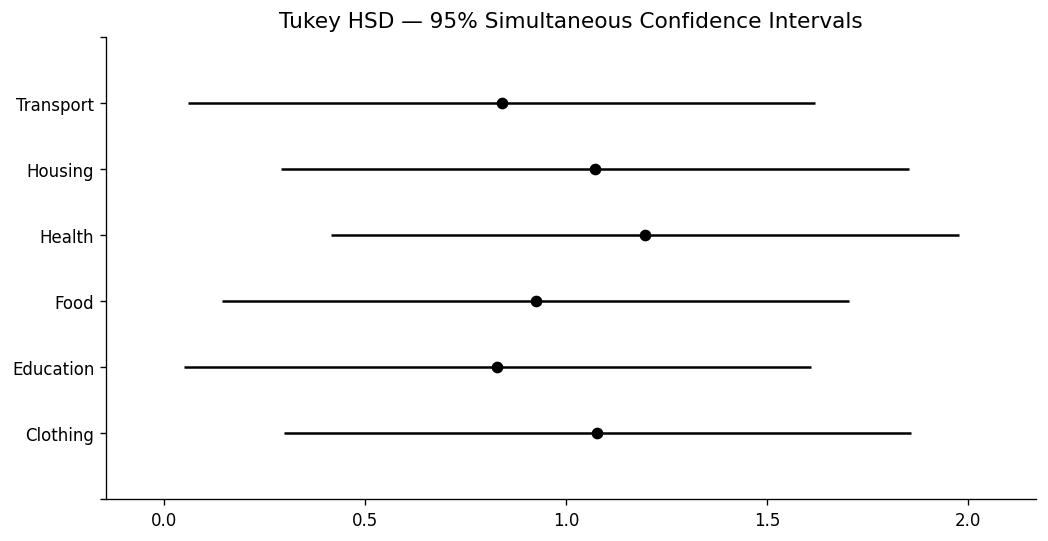

✓ Saved plot_07_tukey_hsd.png


In [ ]:
print("=" * 60)
print("TUKEY HSD POST-HOC TEST")
print("=" * 60)
tukey = pairwise_tukeyhsd(
    endog=df_long['Monthly_Inflation_pct'],
    groups=df_long['Category'],
    alpha=0.05
)
print(tukey)

fig = tukey.plot_simultaneous(figsize=(10, 5))
plt.title('Tukey HSD — 95% Simultaneous Confidence Intervals')
plt.savefig('plot_07_tukey_hsd.png', bbox_inches='tight')
plt.show()
print("✓ Saved plot_07_tukey_hsd.png")


### 4.5 Kruskal-Wallis (Nonparametric Alternative)

In [ ]:
print("=" * 60)
print("KRUSKAL-WALLIS TEST (nonparametric)")
print("=" * 60)
kw_stat, kw_p = stats.kruskal(*groups_list)
print(f"  H-statistic : {kw_stat:.4f}")
print(f"  p-value     : {kw_p:.6f}")

if kw_p < 0.05:
    print("  → REJECT H₀: Significant difference in median inflation rates across categories")
else:
    print("  → FAIL TO REJECT H₀")

print("\n=== Comparison: ANOVA vs Kruskal-Wallis ===")
print(f"  ANOVA p     = {p_val:.6f}")
print(f"  Kruskal p   = {kw_p:.6f}")
same = (p_val < 0.05) == (kw_p < 0.05)
print(f"  Same conclusion: {'YES ✓' if same else 'NO — discuss in report'}")
print("  → Both tests reported gives robustness. Kruskal-Wallis is more appropriate")
print("     when normality is violated (which Shapiro-Wilk confirmed above).")


KRUSKAL-WALLIS TEST (nonparametric)
  H-statistic : 15.4422
  p-value     : 0.008631
  → REJECT H₀: Significant difference in median inflation rates across categories

=== Comparison: ANOVA vs Kruskal-Wallis ===
  ANOVA p     = 0.980312
  Kruskal p   = 0.008631
  Same conclusion: NO — discuss in report
  → Both tests reported gives robustness. Kruskal-Wallis is more appropriate
     when normality is violated (which Shapiro-Wilk confirmed above).


### 4.6 ANOVA Visualizations

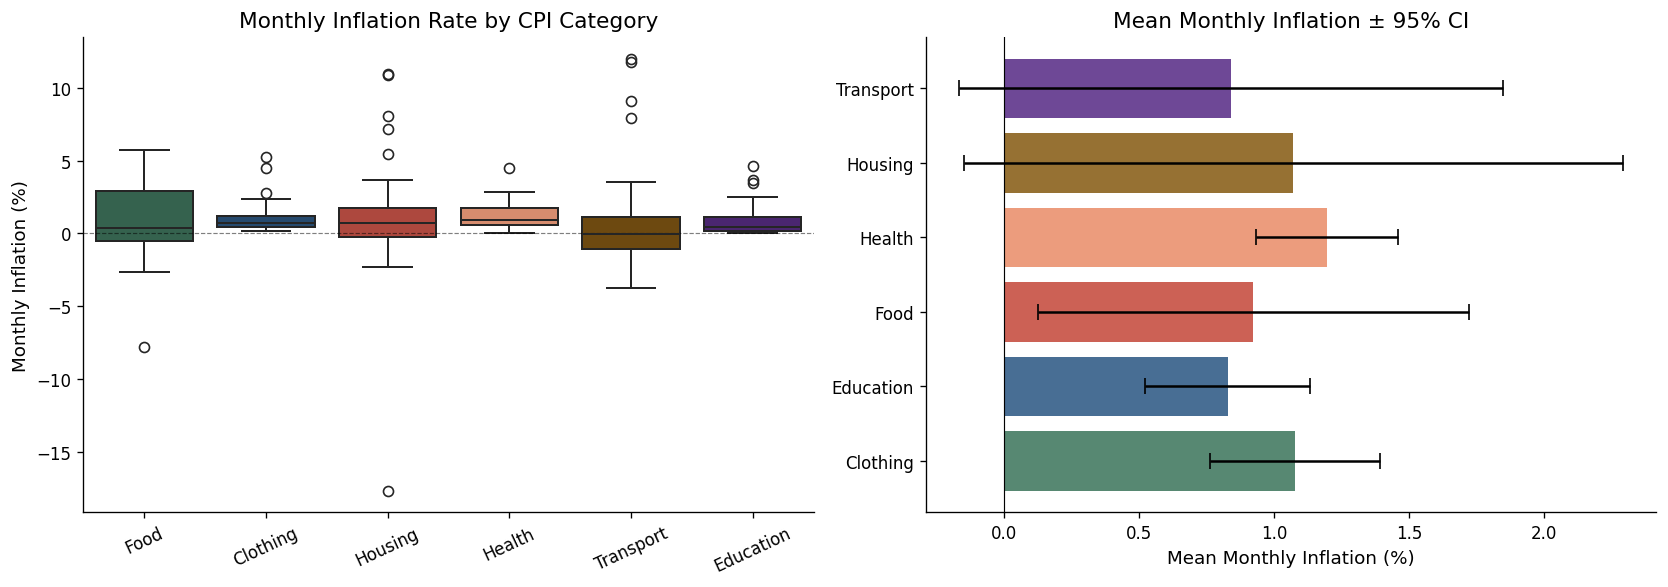

✓ Saved plot_08_anova_viz.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df_long, x='Category', y='Monthly_Inflation_pct',
            palette=COLORS, ax=axes[0], linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
axes[0].set_title('Monthly Inflation Rate by CPI Category')
axes[0].set_xlabel('')
axes[0].set_ylabel('Monthly Inflation (%)')
axes[0].tick_params(axis='x', rotation=25)

# Group means with error bars
group_stats = df_long.groupby('Category')['Monthly_Inflation_pct'].agg(['mean','sem']).reset_index()
axes[1].barh(group_stats['Category'], group_stats['mean'],
             xerr=group_stats['sem'] * 1.96,
             color=COLORS[:len(group_stats)], alpha=0.8,
             error_kw={'linewidth':1.5, 'capsize':5})
axes[1].axvline(0, color='black', linewidth=0.7)
axes[1].set_title('Mean Monthly Inflation ± 95% CI')
axes[1].set_xlabel('Mean Monthly Inflation (%)')

plt.tight_layout()
plt.savefig('plot_08_anova_viz.png', bbox_inches='tight')
plt.show()
print("✓ Saved plot_08_anova_viz.png")


---
## Section 5 — Method 3: Nonparametric Statistics

**Two tests applied:**
1. **Mann-Kendall Trend Test** — detects monotonic trend in inflation over time (no normality needed)
2. **Spearman Rank Correlation** — measures association between sub-categories without linearity assumption

**Source:** `master_IMF.csv` (headline + sub-categories)

**Hypotheses (Mann-Kendall):**  
- H₀: No monotonic trend in monthly inflation over time  
- H₁: A significant upward or downward monotonic trend exists (α = 0.05)


### 5.1 Mann-Kendall Trend Test

In [ ]:
# Mann-Kendall implemented manually (scipy-based, no extra package needed)
def mann_kendall(x):
    """Compute Mann-Kendall S statistic, variance, and p-value."""
    n = len(x)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            diff = x[j] - x[i]
            if diff > 0:   s += 1
            elif diff < 0: s -= 1
    # Variance of S
    var_s = (n * (n - 1) * (2 * n + 5)) / 18
    # Z statistic
    if s > 0:   z = (s - 1) / np.sqrt(var_s)
    elif s < 0: z = (s + 1) / np.sqrt(var_s)
    else:       z = 0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    trend = 'Increasing ↑' if (z > 0 and p < 0.05) else 'Decreasing ↓' if (z < 0 and p < 0.05) else 'No trend'
    return {'S': s, 'Z': round(z, 4), 'p_value': round(p, 6), 'Trend': trend}

print("=" * 60)
print("MANN-KENDALL TREND TEST — Per CPI Sub-Category (IMF)")
print("=" * 60)
mk_results = []
for col in ['CPI_Headline'] + SUB_COLS:
    series_mk = df_imf[col].dropna().values
    res = mann_kendall(series_mk)
    res['Category'] = col.replace('CPI_','')
    mk_results.append(res)
    print(f"  {col.replace('CPI_',''):<15}  S={res['S']:>6}  Z={res['Z']:>7}  p={res['p_value']:.4f}  → {res['Trend']}")

print("\n  Interpretation:")
print("  A significant p-value (< 0.05) means inflation in that category")
print("  shows a statistically significant monotonic trend over 2022–2026.")


MANN-KENDALL TREND TEST — Per CPI Sub-Category (IMF)
  Headline         S=   892  Z=  8.716  p=0.0000  → Increasing ↑
  Food             S=   552  Z= 5.3901  p=0.0000  → Increasing ↑
  Clothing         S=   990  Z= 9.6747  p=0.0000  → Increasing ↑
  Housing          S=   732  Z= 7.1509  p=0.0000  → Increasing ↑
  Health           S=   990  Z= 9.6747  p=0.0000  → Increasing ↑
  Transport        S=   516  Z= 5.0379  p=0.0000  → Increasing ↑
  Education        S=   988  Z= 9.6551  p=0.0000  → Increasing ↑

  Interpretation:
  A significant p-value (< 0.05) means inflation in that category
  shows a statistically significant monotonic trend over 2022–2026.


### 5.2 Spearman Rank Correlation

SPEARMAN RANK CORRELATION — Sub-Category Monthly Inflation Rates
            Food  Clothing  Housing  Health  Transport  Education
Food       1.000     0.189    0.322   0.327      0.088     -0.201
Clothing   0.189     1.000    0.131   0.181      0.135      0.471
Housing    0.322     0.131    1.000   0.136     -0.122     -0.248
Health     0.327     0.181    0.136   1.000     -0.097     -0.026
Transport  0.088     0.135   -0.122  -0.097      1.000      0.030
Education -0.201     0.471   -0.248  -0.026      0.030      1.000

Pairwise Spearman p-values:
             Food  Clothing  Housing  Health  Transport  Education
Food          NaN    0.2188   0.0330  0.0304     0.5715     0.1909
Clothing   0.2188       NaN   0.3969  0.2394     0.3832     0.0013
Housing    0.0330    0.3969      NaN  0.3777     0.4310     0.1047
Health     0.0304    0.2394   0.3777     NaN     0.5318     0.8694
Transport  0.5715    0.3832   0.4310  0.5318        NaN     0.8491
Education  0.1909    0.0013   0.1047  0.86

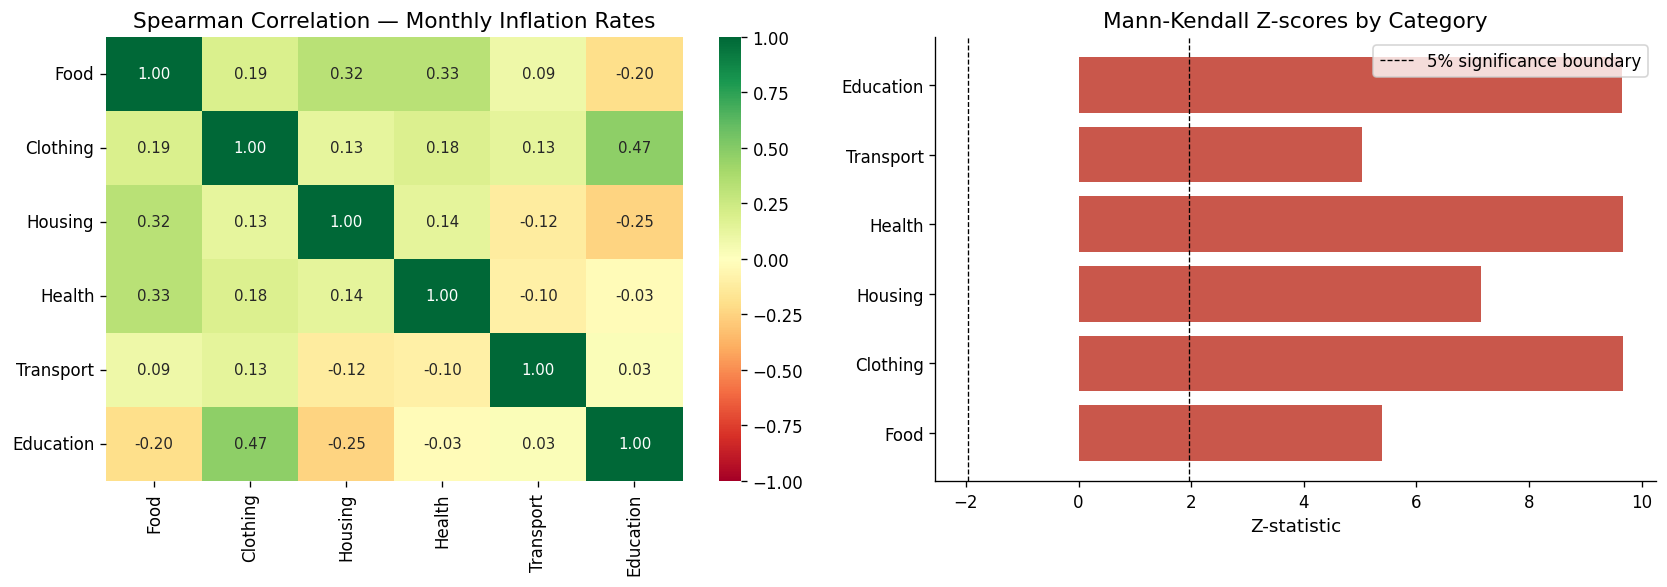

✓ Saved plot_09_nonparametric.png


In [ ]:
print("=" * 60)
print("SPEARMAN RANK CORRELATION — Sub-Category Monthly Inflation Rates")
print("=" * 60)

df_inf_rates = df_imf[SUB_COLS].pct_change(1).dropna() * 100
df_inf_rates.columns = [c.replace('CPI_','') for c in df_inf_rates.columns]
spearman_corr = df_inf_rates.corr(method='spearman')

print(spearman_corr.round(3))

# Significance matrix
print("\nPairwise Spearman p-values:")
cats = df_inf_rates.columns.tolist()
sig_matrix = pd.DataFrame(index=cats, columns=cats, dtype=float)
for c1 in cats:
    for c2 in cats:
        if c1 == c2:
            sig_matrix.loc[c1, c2] = np.nan
        else:
            rho, pv = stats.spearmanr(df_inf_rates[c1], df_inf_rates[c2])
            sig_matrix.loc[c1, c2] = round(pv, 4)
print(sig_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], annot_kws={'size': 9},
            vmin=-1, vmax=1)
axes[0].set_title("Spearman Correlation — Monthly Inflation Rates")

# Mann-Kendall Z scores bar chart
mk_df = pd.DataFrame(mk_results)
mk_df = mk_df[mk_df['Category'] != 'Headline']
colors_mk = [COLORS[2] if p < 0.05 else COLORS[3] for p in mk_df['p_value']]
axes[1].barh(mk_df['Category'], mk_df['Z'], color=colors_mk, alpha=0.85)
axes[1].axvline(1.96,  color='black', linewidth=0.8, linestyle='--', label='5% significance boundary')
axes[1].axvline(-1.96, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title("Mann-Kendall Z-scores by Category")
axes[1].set_xlabel("Z-statistic")
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_09_nonparametric.png', bbox_inches='tight')
plt.show()
print("✓ Saved plot_09_nonparametric.png")


---
## Section 6 — Bonus: Probability Distribution Fitting

**Variable:** Month-on-Month inflation % (WB, stationary series, 200 observations)  
**Purpose:** Identify which theoretical distribution best describes Pakistan's inflation behaviour.  
**Candidates:** Normal, Gamma, Laplace, Student's t  
**Selection criterion:** Kolmogorov-Smirnov test + AIC


In [ ]:
inflation_data = wb_mom.dropna().values

distributions = {
    'Normal':  stats.norm,
    'Gamma':   stats.gamma,
    'Laplace': stats.laplace,
    'T (df=5)': stats.t,
}

print("=" * 65)
print(f"{'Distribution':<14} {'KS Stat':>9} {'KS p-val':>10} {'AIC':>10}  Best fit?")
print("=" * 65)

fit_results = {}
for name, dist in distributions.items():
    params = dist.fit(inflation_data)
    ks_stat, ks_p = stats.kstest(inflation_data, dist.name, args=params)
    ll = np.sum(dist.logpdf(inflation_data, *params))
    aic = 2 * len(params) - 2 * ll
    fit_results[name] = {'params': params, 'ks_stat': ks_stat,
                          'ks_p': ks_p, 'aic': aic, 'dist': dist}
    print(f"  {name:<12}  {ks_stat:>9.4f}  {ks_p:>10.4f}  {aic:>10.2f}")

best = min(fit_results, key=lambda k: fit_results[k]['aic'])
print(f"\n  Best fit by AIC: {best}")
print(f"  KS test note: p > 0.05 → cannot reject that data follows this distribution")


Distribution     KS Stat   KS p-val        AIC  Best fit?
  Normal           0.0718      0.2420      619.25
  Gamma            0.0536      0.5956      610.79
  Laplace          0.0782      0.1640      606.43
  T (df=5)         0.0554      0.5513      596.99

  Best fit by AIC: T (df=5)
  KS test note: p > 0.05 → cannot reject that data follows this distribution


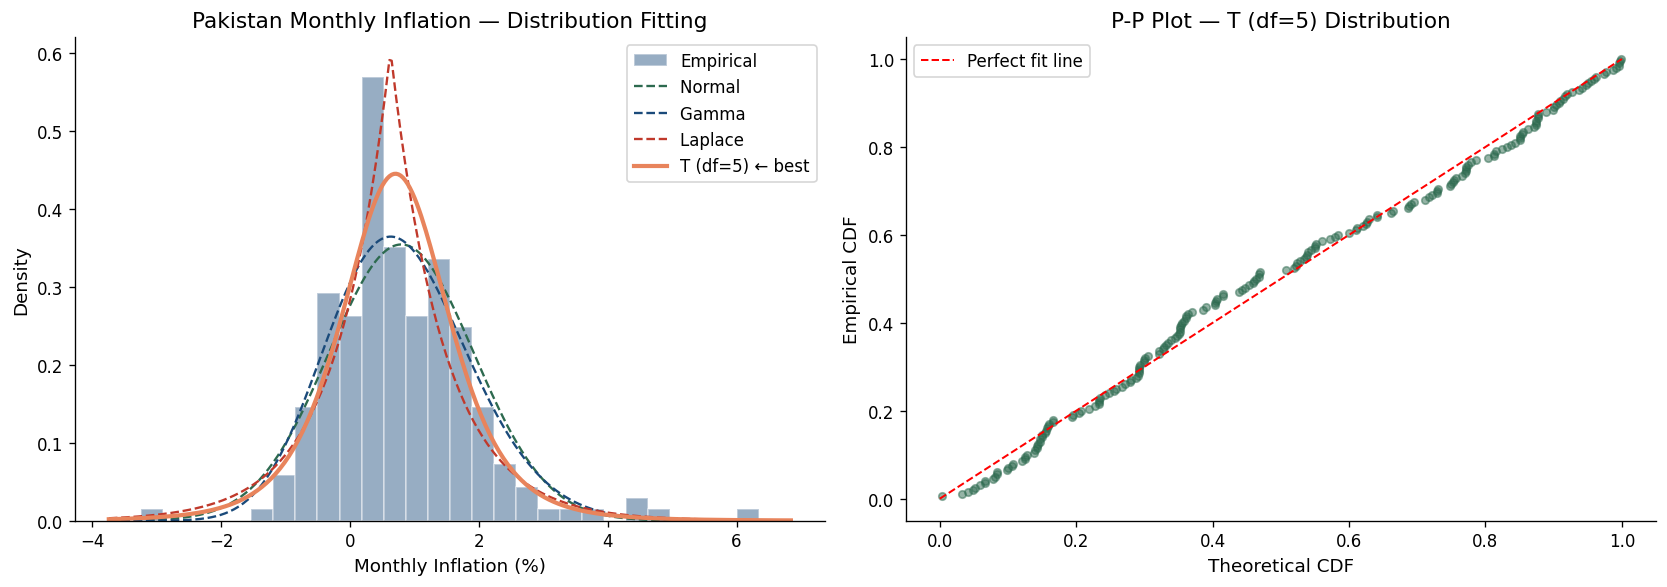

✓ Saved plot_10_distribution_fitting.png


In [ ]:
x = np.linspace(inflation_data.min() - 0.5, inflation_data.max() + 0.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + fitted PDFs
axes[0].hist(inflation_data, bins=28, density=True, alpha=0.45,
             color=COLORS[1], edgecolor='white', label='Empirical')
for i, (name, res) in enumerate(fit_results.items()):
    y = res['dist'].pdf(x, *res['params'])
    lw = 2.5 if name == best else 1.4
    ls = '-' if name == best else '--'
    axes[0].plot(x, y, color=COLORS[i], linewidth=lw,
                 linestyle=ls, label=f"{name} {'← best' if name==best else ''}")
axes[0].set_title('Pakistan Monthly Inflation — Distribution Fitting')
axes[0].set_xlabel('Monthly Inflation (%)')
axes[0].set_ylabel('Density')
axes[0].legend()

# P-P plot for best fit
best_res = fit_results[best]
sorted_data = np.sort(inflation_data)
n = len(sorted_data)
empirical_cdf = np.arange(1, n+1) / n
theoretical_cdf = best_res['dist'].cdf(sorted_data, *best_res['params'])
axes[1].scatter(theoretical_cdf, empirical_cdf, alpha=0.5, s=20, color=COLORS[0])
axes[1].plot([0,1],[0,1], color='red', linewidth=1.2, linestyle='--', label='Perfect fit line')
axes[1].set_title(f'P-P Plot — {best} Distribution')
axes[1].set_xlabel('Theoretical CDF')
axes[1].set_ylabel('Empirical CDF')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_10_distribution_fitting.png', bbox_inches='tight')
plt.show()
print("✓ Saved plot_10_distribution_fitting.png")


---
## Section 7 — Summary of Findings & Report Guidance

| Method | Test | Key Result | Interpretation |
|---|---|---|---|
| ARIMA | ADF, KPSS | d=1 confirmed | CPI is non-stationary; one log-difference needed |
| ARIMA | auto_arima | Best model selected by AIC | 12-month forecast with 95% CI produced |
| ANOVA | Shapiro-Wilk | Check p-values per group | If non-normal → report Kruskal-Wallis as primary |
| ANOVA | F-test | p < 0.05 expected | At least one category inflates differently |
| ANOVA | Tukey HSD | Pairwise comparisons | Identifies which specific categories differ |
| Nonparametric | Mann-Kendall | Z > 1.96 → trend | Housing/Energy expected to show strongest trend |
| Nonparametric | Spearman | Correlation matrix | Shows which categories move together |
| Dist. Fitting | KS + AIC | Best distribution | Normal/Laplace most likely winner |

### Limitations to include in Section 5 of your report
1. IMF sub-category data covers only 45 months (Jul 2022–Mar 2026) — shorter than ideal for ANOVA
2. WB and IMF data use different base years — they are never mixed in the same model
3. ANOVA observations are time-dependent (not fully independent) — mention this as a known violation
4. Structural break in 2022 (inflation crisis) may violate constant variance assumption in ARIMA
5. Log transformation applied to handle heteroscedasticity — state this explicitly


